# 06. 실험 3 — 공통 α로 보정하면 시군 오차가 줄어드는가 (간이 LORO)

**한 줄 요약:** 실험 2(05)에서 이미 저장해 둔 예측 결과만 다시 읽는다. **RF 재학습 없음, 몇 분이면 끝난다.**

**쉬운 설명**
- 실험 2 결과: 모델을 보정 없이 쓰면 시군 탄소가 −1.4% ~ +2.4% 틀린다. 지역마다 방향이 다르다.
- α = 보정 세기 (0 = 보정 안 함, 1 = 지역 차이를 전부 지움). 지역마다 "딱 맞는 α"(α\*)가 있다. 정답을 알아야 찾을 수 있다.
- 새 지역에는 정답이 없다. 그래서 **나머지 7곳의 α\* 중앙값**을 그 지역에 쓴다. 이게 실제 사용 상황을 흉내 낸 것이다.
- 이걸로 8곳 각각의 오차가 줄어드는지 본다.

**순서:** [1] 설정 → [2] 사전 기록(사람이 확정, 확정 전엔 여기서 멈춤) → [3] 함수 → [4] 결과 읽기·검산 → [5] α\* → [6] 적용 → [7] 사전 기록과 대조 → [8] 기록 항목 → [9] 그림·저장

**지킬 것 (인수인계 30절):** [2]를 확정하기 전에 α 스윕 결과를 보지 않는다. 판정은 사전 기록 규칙 그대로.


In [ ]:
# [1] 설정 — 05와 같은 경로·지역·격자. RF·영상은 쓰지 않는다
import os, json, time
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
from google.colab import drive

drive.mount('/content/drive')
OUT = '/content/drive/MyDrive/forest/outputs'

TRAIN_REGIONS = ['inje', 'hongcheon', 'gangneung', 'pyeongchang',
                 'bonghwa', 'geumsan', 'geochang', 'suncheon']
LAT   = {'inje': 38.04, 'hongcheon': 37.75, 'gangneung': 37.71, 'pyeongchang': 37.54,
         'bonghwa': 36.92, 'geumsan': 36.13, 'geochang': 35.71, 'suncheon': 35.01}
LARCH = {'inje': 19.0, 'hongcheon': 37.4, 'gangneung': 11.0, 'pyeongchang': 45.8,
         'bonghwa': 16.7, 'geumsan': 19.5, 'geochang': 11.7, 'suncheon': 0.0}
SEEDS  = [16, 17, 18, 19, 20]
ALPHAS = [0.0, 0.25, 0.40, 0.50, 0.60, 0.75, 1.0]   # 05 [1]과 동일 (exp2_results.npz에 저장된 격자)

# 탄소계수 [확정] — 이 노트북은 05가 계산한 탄소값을 읽기만 하므로 직접 쓰지 않는다 (기록용)
C = {1: 79.25, 2: 101.02, 3: 92.01}

assert os.path.exists(f'{OUT}/exp2_results.npz'), '05를 먼저 끝낼 것 (exp2_results.npz 없음)'
print('설정 완료')


Mounted at /content/drive
설정 완료


## 실험 3 사전 기록 — 결과를 보기 전에 확정

8일차 채팅에서 사용자가 승인한 내용으로 채워 두었다. **읽어 보고 맞으면 `CONFIRMED = True`로 바꾼 뒤 실행.**

| 항목 | 내용 (쉬운 말) |
|---|---|
| α\*가 없는 지역 | 0–1 사이에서 오차가 0을 안 지나면, **오차가 가장 작았던 α**를 대신 쓴다. 몇 곳이었는지 같이 보고 |
| 7곳을 합치는 법 | **중앙값** (한 곳이 튀어도 덜 흔들림) |
| 적용 α | 중앙값을 **가장 가까운 격자점**(0, .25, .4, .5, .6, .75, 1)으로 맞춘다. 실제로 예측해 본 값만 쓰기 위해 (보간 추정값을 쓰지 않음) |
| A. 보정 효과 | 오차(절댓값)가 줄어든 지역 8곳 중 **6곳 이상** + 평균 개선 **0.1%p 초과** |
| C. F1 유지 | F1이 안 떨어진 지역 8곳 중 **6곳 이상** |
| D. 안정성 | A·C가 **시드 5번 모두** 성립해야 통과 |
| 기록만 (판정 없음) | B(공통 α vs 지역별 최적 α 차이 — 허용치는 김현배 연구실 확인 후), 합산 치우침 +1.03%의 변화, 지역 단위 기준선 비교, α\*와 위도·낙엽송%의 관계 |

한 번 저장된 `exp3_prereg.json`은 덮어쓰지 않는다. 바꾸려면 파일을 직접 지우고 이유를 기록할 것.


In [ ]:
# [2] 사전 기록 — 확정 전에는 여기서 멈춘다 (정상 정지)
CONFIRMED = True   # ← 위 표를 읽고 맞으면 True로 바꾼다

PREREG = {
    'date': time.strftime('%Y-%m-%d %H:%M'),
    'seen_before_prereg': 'exp2_results.npz의 α=0 열만 (05 [9]–[11]). α 스윕은 미확인. 05 [11] 그림에 α 곡선 없음',
    'data': 'exp2_folds/ 40폴드의 α 스윕 예측 (RF 재학습 없음)',
    'alpha_grid': ALPHAS,
    'alpha_star': '탄소 오차가 처음 부호를 바꾸는 격자 구간에서 선형 보간 (04 alpha_star 원본)',
    'no_crossing_rule': '0을 안 지나면 |오차| 최소 격자 α로 대체, 해당 폴드 수 보고. 평균에서 제외하지 않음',
    'combine': 'median — 같은 시드의 나머지 7지역 α* 중앙값',
    'apply': '중앙값에 가장 가까운 격자점 (거리가 같으면 작은 쪽). 보간 추정값 사용 안 함',
    'method': '간이 (12절). 나머지 폴드 모델이 평가 지역 라벨로 학습됐으므로 약간의 누설 있음 — 결과와 함께 명시',
    'criteria': {
        'A': '시드마다: |오차|가 α=0보다 줄어든 지역 >= 6/8 AND 지역 평균 개선폭(|e0|-|eα|) > 0.1 %p (시드 sd 최대치)',
        'C': '시드마다: F1(α) >= F1(α=0) 인 지역 >= 6/8',
        'D': '5/5 시드에서 A와 C 모두 성립 → 통과',
    },
    'record_only': [
        'B: 적용 α의 |오차| − 그 지역 최적 격자 α의 |오차| (허용치 미정, 김현배 연구실)',
        '면적가중 합산 오차 (α=0: +1.03%)',
        '지역 단위 기준선 비교 (α=0: RF가 나은 폴드 30/40). 합산 기준선 비교는 하지 않음 (28-4)',
        'α*와 위도·낙엽송% Spearman — 결론 내지 않음 (6절 5항)',
    ],
    'failure_report': '통과 못 하면 실패라고 먼저 쓰고 원인을 함께 쓴다. 기준을 결과 보고 바꾸지 않는다',
}

PRE = f'{OUT}/exp3_prereg.json'
if os.path.exists(PRE):
    print('이미 저장된 사전 기록을 사용 (덮어쓰지 않음):', PRE)
else:
    assert CONFIRMED, '사전 기록을 읽고 CONFIRMED = True로 바꾼 뒤 다시 실행 (정상 정지)'
    json.dump(PREREG, open(PRE, 'w', encoding='utf-8'), ensure_ascii=False, indent=2)
    print('사전 기록 저장:', PRE)
print(json.dumps(json.load(open(PRE, encoding='utf-8')), ensure_ascii=False, indent=2))


사전 기록 저장: /content/drive/MyDrive/forest/outputs/exp3_prereg.json
{
  "date": "2026-10-03 05:23",
  "seen_before_prereg": "exp2_results.npz의 α=0 열만 (05 [9]–[11]). α 스윕은 미확인. 05 [11] 그림에 α 곡선 없음",
  "data": "exp2_folds/ 40폴드의 α 스윕 예측 (RF 재학습 없음)",
  "alpha_grid": [
    0.0,
    0.25,
    0.4,
    0.5,
    0.6,
    0.75,
    1.0
  ],
  "alpha_star": "탄소 오차가 처음 부호를 바꾸는 격자 구간에서 선형 보간 (04 alpha_star 원본)",
  "no_crossing_rule": "0을 안 지나면 |오차| 최소 격자 α로 대체, 해당 폴드 수 보고. 평균에서 제외하지 않음",
  "combine": "median — 같은 시드의 나머지 7지역 α* 중앙값",
  "apply": "중앙값에 가장 가까운 격자점 (거리가 같으면 작은 쪽). 보간 추정값 사용 안 함",
  "method": "간이 (12절). 나머지 폴드 모델이 평가 지역 라벨로 학습됐으므로 약간의 누설 있음 — 결과와 함께 명시",
  "criteria": {
    "A": "시드마다: |오차|가 α=0보다 줄어든 지역 >= 6/8 AND 지역 평균 개선폭(|e0|-|eα|) > 0.1 %p (시드 sd 최대치)",
    "C": "시드마다: F1(α) >= F1(α=0) 인 지역 >= 6/8",
    "D": "5/5 시드에서 A와 C 모두 성립 → 통과"
  },
  "record_only": [
    "B: 적용 α의 |오차| − 그 지역 최적 격자 α의 |오차| (허용치 미정, 김현배 연구실)",
    "면적가중 합산 오차 (α=0: +1.03%)",
    "지역 단위 기준선 비교 (α=0: RF가 나은 폴드

In [ ]:
# [3] 함수
def alpha_star_1d(y, alphas=ALPHAS):
    # 04 alpha_star 원본(한 곡선용): 처음 부호가 바뀌는 구간에서 선형 보간. 없으면 NaN
    k = next((t for t in range(len(alphas) - 1) if y[t] * y[t + 1] < 0), None)
    if k is None:
        return np.nan
    return alphas[k] + (alphas[k + 1] - alphas[k]) * abs(y[k]) / (abs(y[k]) + abs(y[k + 1]))

def n_crossings(y):
    return int(sum(y[t] * y[t + 1] < 0 for t in range(len(y) - 1)))

def nearest_grid(a, alphas=ALPHAS):
    # 가장 가까운 격자 인덱스. 거리가 같으면 작은 α (argmin은 앞쪽을 고름)
    return int(np.argmin(np.abs(np.array(alphas) - a)))

print('함수 정의 완료')


함수 정의 완료


In [ ]:
# [4] 결과 읽기 + 검산 (α=0이 28-3절 값과 같아야 함)
assert os.path.exists(f'{OUT}/exp3_prereg.json'), '[2] 사전 기록을 먼저 확정 (정상 정지)'

z = np.load(f'{OUT}/exp2_results.npz')
print('키:', z.files)
CARB, F1, PC = z['carb'], z['f1'], z['p_c']          # (시드, 지역, α)
TC, NT, BASE = z['t_c'], z['n_test'], z['base_err']  # (시드, 지역)
NTOT = z['n_total']                                  # (지역,)
assert list(z['regions']) == TRAIN_REGIONS, '지역 순서 불일치'
assert list(z['seeds']) == SEEDS, '시드 불일치'
assert np.allclose(z['alphas'], ALPHAS), '격자 불일치'
assert CARB.shape == (5, 8, 7) and not np.isnan(CARB).any()
ns, nr, na = CARB.shape
j0 = 0

# 28-3절 표 (5시드 평균, 소수 셋째 자리)
REF = {'inje': 2.397, 'hongcheon': 0.729, 'gangneung': -0.469, 'pyeongchang': 2.382,
       'bonghwa': 1.192, 'geumsan': 2.167, 'geochang': 0.377, 'suncheon': -1.364}
got = CARB[:, :, j0].mean(0)
ok = all(abs(got[j] - REF[r]) < 0.0015 for j, r in enumerate(TRAIN_REGIONS))

def aggregate(j_idx):
    # j_idx: (시드, 지역) 격자 인덱스 → 시드별 면적가중 합산 오차 %
    dens_t = TC / NT
    dens_p = np.take_along_axis(PC, j_idx[:, :, None], axis=2)[:, :, 0] / NT
    tot_t = (dens_t * NTOT).sum(1)
    return ((dens_p * NTOT).sum(1) - tot_t) * 100 / tot_t

agg0 = aggregate(np.zeros((ns, nr), int))
print('α=0 지역 평균 오차:', ' '.join(f'{r[:4]} {g:+.3f}' for r, g in zip(TRAIN_REGIONS, got)))
print(f'α=0 합산 {agg0.mean():+.2f}%  (28-3절: +1.03)')
assert ok and abs(agg0.mean() - 1.03) < 0.006, '검산 실패 — 28-3절과 다름. 여기서 멈추고 원인 확인'
print('검산 통과')


키: ['carb', 'f1', 'p_c', 't_c', 'n_test', 'base_err', 'n_total', 'seeds', 'regions', 'alphas']
α=0 지역 평균 오차: inje +2.397 hong +0.729 gang -0.469 pyeo +2.382 bong +1.192 geum +2.167 geoc +0.377 sunc -1.364
α=0 합산 +1.03%  (28-3절: +1.03)
검산 통과


In [ ]:
# [5] 지역마다 α* (정답을 보고 찾은 '딱 맞는 보정 세기')
AST   = np.full((ns, nr), np.nan)   # 사용값 (교차 없으면 대체값)
NOCR  = np.zeros((ns, nr), bool)    # 교차 없음 → 대체
MULTI = np.zeros((ns, nr), bool)    # 교차 2번 이상 (첫 교차 사용)
for i in range(ns):
    for j in range(nr):
        y = CARB[i, j]
        a = alpha_star_1d(y)
        MULTI[i, j] = n_crossings(y) > 1
        if np.isnan(a):
            NOCR[i, j] = True
            a = ALPHAS[int(np.argmin(np.abs(y)))]
        AST[i, j] = a

print(pd.DataFrame(AST.T, index=TRAIN_REGIONS, columns=[f's{s}' for s in SEEDS]).round(3).to_string())
print(f'\n교차 없음(대체) {NOCR.sum()}/{NOCR.size} 폴드:',
      sorted({TRAIN_REGIONS[j] for i, j in zip(*np.where(NOCR))}))
print(f'교차 2번 이상 {MULTI.sum()}/{MULTI.size} 폴드')


               s16    s17    s18    s19    s20
inje         1.000  1.000  1.000  1.000  1.000
hongcheon    0.407  0.430  0.418  0.430  0.446
gangneung    0.773  0.673  0.770  0.757  0.688
pyeongchang  0.959  0.961  0.930  0.967  0.937
bonghwa      0.000  0.000  0.000  0.000  0.000
geumsan      0.510  0.507  0.496  0.502  0.508
geochang     0.000  0.000  0.000  0.000  0.000
suncheon     0.242  0.216  0.256  0.226  0.240

교차 없음(대체) 15/40 폴드: ['bonghwa', 'geochang', 'inje']
교차 2번 이상 0/40 폴드


In [ ]:
# [6] 간이 LORO 적용: 지역 r에는 '나머지 7곳 α*의 중앙값' → 가까운 격자점
A_MED = np.full((ns, nr), np.nan)
J     = np.zeros((ns, nr), int)
for i in range(ns):
    for j in range(nr):
        A_MED[i, j] = np.median(np.delete(AST[i], j))
        J[i, j] = nearest_grid(A_MED[i, j])
A_APP = np.array(ALPHAS)[J]

take = lambda M: np.take_along_axis(M, J[:, :, None], axis=2)[:, :, 0]
E0, EA = CARB[:, :, j0], take(CARB)
F0, FA = F1[:, :, j0],   take(F1)

tab = pd.DataFrame({
    'α_applied(시드별)': [' '.join(f'{x:.2f}' for x in A_APP[:, j]) for j in range(nr)],
    'err_α0': E0.mean(0), 'err_α': EA.mean(0),
    '|err| 줄어든 시드': [f'{int((np.abs(EA[:, j]) < np.abs(E0[:, j])).sum())}/{ns}' for j in range(nr)],
    'F1_α0': F0.mean(0), 'F1_α': FA.mean(0),
}, index=TRAIN_REGIONS)
print(tab.round(3).to_string())


                       α_applied(시드별)  err_α0  err_α |err| 줄어든 시드  F1_α0   F1_α
inje         0.40 0.40 0.40 0.40 0.40   2.397  1.908          5/5  0.603  0.611
hongcheon    0.50 0.50 0.50 0.50 0.50   0.729 -0.134          5/5  0.616  0.612
gangneung    0.40 0.40 0.40 0.40 0.40  -0.469 -0.205          5/5  0.611  0.613
pyeongchang  0.40 0.40 0.40 0.40 0.40   2.382  1.445          5/5  0.616  0.618
bonghwa      0.50 0.50 0.50 0.50 0.50   1.192  2.978          0/5  0.596  0.579
geumsan      0.40 0.40 0.40 0.40 0.40   2.167  0.459          5/5  0.514  0.516
geochang     0.50 0.50 0.50 0.50 0.50   0.377  2.224          0/5  0.631  0.632
suncheon     0.50 0.50 0.50 0.50 0.50  -1.364  1.316          3/5  0.555  0.605


In [ ]:
# [7] 사전 기록과 대조 — 규칙 그대로 계산만. 판정 문장은 사람이 쓴다
impA_n   = (np.abs(EA) < np.abs(E0)).sum(1)          # 시드별: 줄어든 지역 수
impA_mag = (np.abs(E0) - np.abs(EA)).mean(1)         # 시드별: 평균 개선폭 %p
okC_n    = (FA >= F0).sum(1)
A_pass = (impA_n >= 6) & (impA_mag > 0.1)
C_pass = okC_n >= 6

print(f'{"seed":>5} {"A 줄어든 지역":>12} {"A 평균개선 %p":>13} {"A":>4} {"C F1유지 지역":>12} {"C":>4}')
for i, s in enumerate(SEEDS):
    print(f'{s:>5} {impA_n[i]:>10d}/8 {impA_mag[i]:>+13.3f} {"O" if A_pass[i] else "X":>4} '
          f'{okC_n[i]:>10d}/8 {"O" if C_pass[i] else "X":>4}')
D_pass = bool(A_pass.all() and C_pass.all())
print(f'\nD (5/5 시드에서 A·C 모두): A {A_pass.sum()}/5, C {C_pass.sum()}/5 → {"통과" if D_pass else "미통과"}')
print('※ 간이 방식: 나머지 폴드 모델이 평가 지역 라벨로 학습돼 약간의 누설이 있다 (12절)')


 seed     A 줄어든 지역     A 평균개선 %p    A    C F1유지 지역    C
   16          6/8        +0.041    X          6/8    O
   17          5/8        +0.017    X          5/8    X
   18          6/8        +0.079    X          5/8    X
   19          5/8        +0.047    X          6/8    O
   20          6/8        +0.071    X          6/8    O

D (5/5 시드에서 A·C 모두): A 0/5, C 3/5 → 미통과
※ 간이 방식: 나머지 폴드 모델이 평가 지역 라벨로 학습돼 약간의 누설이 있다 (12절)


In [ ]:
# [8] 기록만 하는 항목 (판정 없음)
# B: 적용 α vs 그 지역 최적 격자 α
best = np.abs(CARB).min(2)
gapB = np.abs(EA) - best
print(f'B 적용−최적 |오차| 차이: 평균 {gapB.mean():.3f} %p, 최대 {gapB.max():.3f} %p  (허용치 미정)')

# 합산
aggA = aggregate(J)
print('합산 오차 α=0 : ' + ' '.join(f'{x:+.2f}' for x in agg0) + f'   평균 {agg0.mean():+.2f}')
print('합산 오차 α   : ' + ' '.join(f'{x:+.2f}' for x in aggA) + f'   평균 {aggA.mean():+.2f}')

# 지역 단위 기준선
print(f'지역 기준선보다 RF가 나은 폴드: α=0 {int((np.abs(E0) < np.abs(BASE)).sum())}/40, '
      f'α {int((np.abs(EA) < np.abs(BASE)).sum())}/40')
print(f'지역 |오차| 평균: α=0 {np.abs(E0).mean():.2f}%, α {np.abs(EA).mean():.2f}%, 기준선 {np.abs(BASE).mean():.2f}%')

# α*와 위도·낙엽송 (결론 내지 않음)
latv, larv = [LAT[r] for r in TRAIN_REGIONS], [LARCH[r] for r in TRAIN_REGIONS]
print('ρ(위도, α*)   : ' + ' '.join(f'{spearmanr(latv, AST[i]).correlation:+.2f}' for i in range(ns)))
print('ρ(낙엽송%, α*): ' + ' '.join(f'{spearmanr(larv, AST[i]).correlation:+.2f}' for i in range(ns)))


B 적용−최적 |오차| 차이: 평균 0.950 %p, 최대 1.905 %p  (허용치 미정)
합산 오차 α=0 : +1.00 +1.05 +1.02 +1.05 +1.06   평균 +1.03
합산 오차 α   : +1.20 +1.26 +1.20 +1.23 +1.23   평균 +1.22
지역 기준선보다 RF가 나은 폴드: α=0 30/40, α 28/40
지역 |오차| 평균: α=0 1.38%, α 1.33%, 기준선 1.84%
ρ(위도, α*)   : +0.67 +0.67 +0.67 +0.67 +0.67
ρ(낙엽송%, α*): +0.42 +0.42 +0.42 +0.42 +0.42


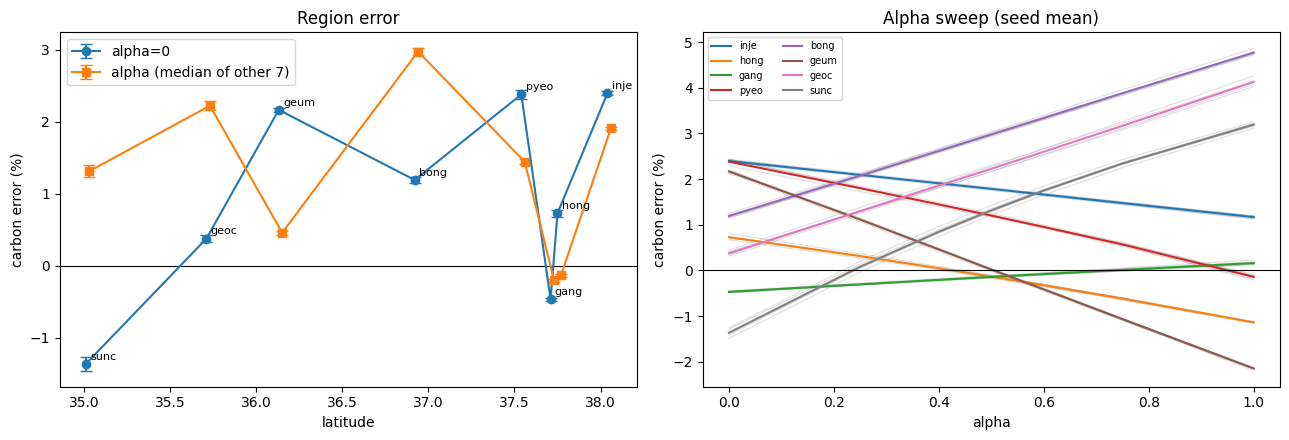

저장: exp3_alpha.png, exp3_by_region.csv, exp3_by_seed.csv, exp3_results.npz
→ [5]–[8] 출력과 그림을 새 채팅에 붙여넣기


In [ ]:
# [9] 그림·저장
lat = np.array(latv); o = np.argsort(lat)
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].axhline(0, c='k', lw=.8)
ax[0].errorbar(lat[o], E0.mean(0)[o], yerr=E0.std(0, ddof=1)[o], fmt='o-', capsize=4, label='alpha=0')
ax[0].errorbar(lat[o] + .02, EA.mean(0)[o], yerr=EA.std(0, ddof=1)[o], fmt='s-', capsize=4, label='alpha (median of other 7)')
for k in o: ax[0].annotate(TRAIN_REGIONS[k][:4], (lat[k], E0.mean(0)[k]), fontsize=8, xytext=(3, 3), textcoords='offset points')
ax[0].set_xlabel('latitude'); ax[0].set_ylabel('carbon error (%)'); ax[0].legend(); ax[0].set_title('Region error')
for i in range(ns):
    ax[1].plot(ALPHAS, CARB[i].T, c='gray', alpha=.25, lw=.8)
for j in range(nr):
    ax[1].plot(ALPHAS, CARB[:, j].mean(0), lw=1.5, label=TRAIN_REGIONS[j][:4])
ax[1].axhline(0, c='k', lw=.8); ax[1].set_xlabel('alpha'); ax[1].set_ylabel('carbon error (%)')
ax[1].set_title('Alpha sweep (seed mean)'); ax[1].legend(fontsize=7, ncol=2)
plt.tight_layout(); plt.savefig(f'{OUT}/exp3_alpha.png', dpi=150); plt.show()

tab.to_csv(f'{OUT}/exp3_by_region.csv')
pd.DataFrame({'seed': SEEDS, 'A_regions': impA_n, 'A_mean_gain_pp': impA_mag, 'A_pass': A_pass,
              'C_regions': okC_n, 'C_pass': C_pass, 'agg_a0': agg0, 'agg_a': aggA}).to_csv(f'{OUT}/exp3_by_seed.csv', index=False)
np.savez(f'{OUT}/exp3_results.npz', alpha_star=AST, no_cross=NOCR, multi_cross=MULTI,
         alpha_median=A_MED, alpha_applied=A_APP, err_a0=E0, err_a=EA, f1_a0=F0, f1_a=FA,
         seeds=np.array(SEEDS), regions=np.array(TRAIN_REGIONS), alphas=np.array(ALPHAS))
print('저장: exp3_alpha.png, exp3_by_region.csv, exp3_by_seed.csv, exp3_results.npz')
print('→ [5]–[8] 출력과 그림을 새 채팅에 붙여넣기')
